In [1]:
#import essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
#import dataset
df=pd.read_csv("student_info.csv")
df.head()

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19


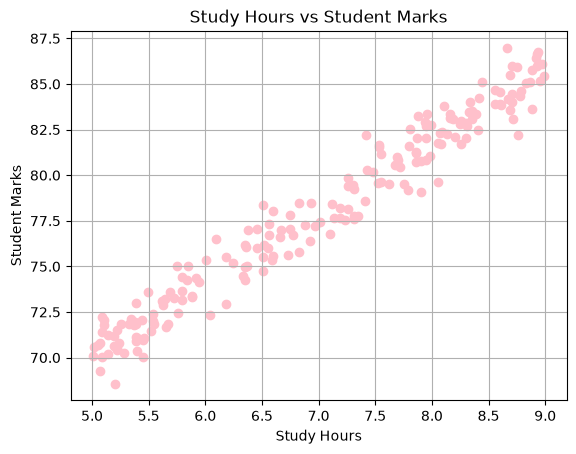

In [3]:
# Data Visualization {Scatter Plot}
x=df.study_hours
y=df.student_marks
plt.scatter(x,y, color='pink')
plt.title("Study Hours vs Student Marks")
plt.xlabel("Study Hours")
plt.ylabel("Student Marks")
plt.grid()
plt.show()

In [4]:
#check for missing values
df.isnull().sum()


study_hours      5
student_marks    0
dtype: int64

In [5]:
# handle missing values
df=df.fillna(df.mean())
df.isnull().sum()

study_hours      0
student_marks    0
dtype: int64

In [6]:
#separate dataset into independent and dependent variables
X=df.drop("student_marks",axis=1)
X.head()

,study_hours
0,6.830000
1,6.560000
2,6.995949
3,5.670000
4,8.670000


In [7]:
y=df.drop("study_hours",axis=1)
y.head()

,student_marks
0,78.50
1,76.74
2,78.68
3,71.82
4,84.19


In [8]:
#Train_Test_Splitting
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [9]:
#Applying Linear Regression Algorithm{used to model the linear relationship between one or more independent variables (predictors) and a single dependent variable (target).}
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[3.93]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['study_hours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[50.45]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [11]:
#Test the model
sh=float(input("Enter the Study Hours: "))
if sh>=4 and  sh<=12:
    res=model.predict([[sh]])[0][0].round(2)
    print("Expected Marks=",res)
else:
    print("Invalid Study Hours")

Expected Marks= 66.17
